In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping 
#에폭= 몇번을 반복해서 학습시킬거냐임. / 무한히는 불가능함(과적합) / 과적합 발생되기 전에 중단시킴.

In [3]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 [==============================] - 2642s 15us/step


In [4]:
print(train_images.shape, train_labels.shape)
print(test_images.shape, test_labels.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


In [5]:
train_images[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

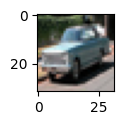

In [6]:
plt.figure(figsize = (1,1))
plt.imshow(train_images[32])

In [7]:
# 정규화
train_images = train_images / 255.0
test_images = test_images / 255.0

In [8]:
train_images[0] # 텐서로 나옴.

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [9]:
val_images = train_images[45000:]
val_labels = train_labels[45000:]

# 남은거 train으로 
train_images = train_images[:45000]
train_labels = train_labels[:45000]

In [10]:
mlp_model = Sequential([
    Flatten(input_shape = (32, 32, 3)),
    Dense(512,activation = "relu"),
    Dense(256, activation = "relu"),
    Dense(128, activation = "relu"),
    Dense(10, activation = "softmax")
])

In [12]:
mlp_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 512)               1573376   
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 128)               32896     
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1738890 (6.63 MB)
Trainable params: 1738890 (6.63 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
mlp_model.compile(
    optimizer = "adam", 
    loss = "sparse_categorical_crossentropy", 
    metrics = ["accuracy"]
    )

In [14]:
mlp_model.fit(
    train_images, 
    train_labels, 
    epochs = 5, 
    validation_data = (val_images, val_labels)
    )

Epoch 1/5


1407/1407 [==============================] - 6s 4ms/step - loss: 1.8820 - accuracy: 0.3207 - val_loss: 1.8056 - val_accuracy: 0.3434
Epoch 2/5
1407/1407 [==============================] - 5s 3ms/step - loss: 1.6894 - accuracy: 0.3923 - val_loss: 1.7373 - val_accuracy: 0.3782
Epoch 3/5
1407/1407 [==============================] - 5s 3ms/step - loss: 1.6080 - accuracy: 0.4243 - val_loss: 1.5769 - val_accuracy: 0.4378
Epoch 4/5
1407/1407 [==============================] - 5s 3ms/step - loss: 1.5463 - accuracy: 0.4460 - val_loss: 1.5781 - val_accuracy: 0.4368
Epoch 5/5
1407/1407 [==============================] - 5s 3ms/step - loss: 1.5102 - accuracy: 0.4589 - val_loss: 1.5363 - val_accuracy: 0.4548


In [15]:
mlp_model.evaluate(test_images, test_labels)
# mlp_model 성능 알아보는것.

313/313 [==============================] - 0s 1ms/step - loss: 1.5245 - accuracy: 0.4529


[1.5245457887649536, 0.4528999924659729]